# MNIST Classification Demo

This Jupyter Notebook demonstrates the usage of the `MnistClassifier` wrapper class for classifying handwritten digits from the MNIST dataset.  
The solution implements three models following the requirements:

- **Random Forest (RF)** - classical ML baseline using scikit-learn  
- **Feed-Forward Neural Network (NN)** - multi-layer perceptron using PyTorch  
- **Convolutional Neural Network (CNN)** - image-specific model using PyTorch  

The `MnistClassifier` wrapper provides a **unified interface** regardless of the selected algorithm (`rf`, `nn`, `cnn`).  

We will:
1. Load and preprocess the MNIST dataset  
2. Train each model (with validation split for NN/CNN to monitor overfitting)  
3. Evaluate on the test set  
4. Visualize predictions, confusion matrices, and learning curves  
5. Demonstrate edge cases  
6. Compare model performance  



In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import mnist

from mnist_classifier import MnistClassifier

c:\Users\aleks\.virtualenvs\goit-ds-hw-02-OF6PVF8m\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\aleks\.virtualenvs\goit-ds-hw-02-OF6PVF8m\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


We fix random seeds to ensure reproducibility of results.

In [3]:
import torch
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Load MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

print("Train dataset:", X_train_full.shape)
print("Test dataset:", X_test.shape)

Train dataset: (60000, 28, 28)
Test dataset: (10000, 28, 28)


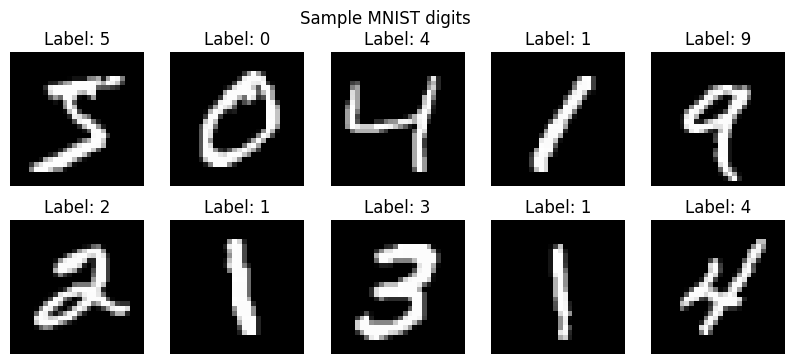

In [5]:
# Display a sample
fig, axes = plt.subplots(2,5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i], cmap="gray")
    ax.set_title(f"Label: {y_train_full[i]}")
    ax.axis("off")

plt.suptitle("Sample MNIST digits")
plt.show()

In [6]:
# Demo subset  + validation split
subset_size = 30000

X_subset = X_train_full[:subset_size]
y_subset = y_train_full[:subset_size]

X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.2,
    random_state=SEED,
    stratify=y_subset
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)

Train set: (24000, 28, 28)
Validation set: (6000, 28, 28)


### Why a subset of the dataset was used

The full MNIST training dataset contains 60000 images.

For demonstration purposes we used a subset of 30000 samples.

Training neural networks on the full dataset would significantly increase execution time of the notebook.   
Using a smaller subset allows the entire pipeline to run quickly while still producing representative results.  
The notebook is intended to demonstrate the functionality of the framework rather than to maximize model performance.

## Model Training and Evaluation

We train each model using the unified `MnistClassifier` interface.  
For NN and CNN we use validation data to monitor overfitting and apply early stopping.  

In [12]:
algorithms = ["rf", "nn", "cnn"]

results = {}
trained_models = {}

In [13]:
for alg in algorithms:

    print(f"Training {alg.upper()} model")

    if alg in ["nn","cnn"]:
        clf = MnistClassifier(alg, epochs=30, batch_size=128, patience=3)
        clf.train(X_train, y_train, X_val=X_val, y_val=y_val)

    else:
        clf = MnistClassifier(alg)
        clf.train(X_train, y_train)

    trained_models[alg] = clf

    preds = clf.predict(X_test)

    test_acc = accuracy_score(y_test, preds)

    results[alg] = {
        "test_accuracy": test_acc,
        "confusion_matrix": confusion_matrix(y_test, preds)
    }

    print("Test accuracy:", test_acc)

Training RF model
Test accuracy: 0.9611
Training NN model
Epoch 1: train_acc=0.6639 val_acc=0.8943
Epoch 2: train_acc=0.8578 val_acc=0.9155
Epoch 3: train_acc=0.8892 val_acc=0.9283
Epoch 4: train_acc=0.9048 val_acc=0.9338
Epoch 5: train_acc=0.9146 val_acc=0.9410
Epoch 6: train_acc=0.9202 val_acc=0.9407
Epoch 7: train_acc=0.9264 val_acc=0.9465
Epoch 8: train_acc=0.9315 val_acc=0.9503
Epoch 9: train_acc=0.9345 val_acc=0.9538
Epoch 10: train_acc=0.9373 val_acc=0.9527
Epoch 11: train_acc=0.9401 val_acc=0.9527
Epoch 12: train_acc=0.9413 val_acc=0.9572
Epoch 13: train_acc=0.9436 val_acc=0.9555
Epoch 14: train_acc=0.9477 val_acc=0.9577
Epoch 15: train_acc=0.9458 val_acc=0.9597
Epoch 16: train_acc=0.9486 val_acc=0.9577
Epoch 17: train_acc=0.9485 val_acc=0.9598
Epoch 18: train_acc=0.9523 val_acc=0.9592
Epoch 19: train_acc=0.9523 val_acc=0.9607
Epoch 20: train_acc=0.9560 val_acc=0.9603
Epoch 21: train_acc=0.9560 val_acc=0.9627
Epoch 22: train_acc=0.9568 val_acc=0.9612
Epoch 23: train_acc=0.9563 

In [14]:
print("Overfitting check")

for alg, clf in trained_models.items():

    train_pred = clf.predict(X_train)

    train_acc = accuracy_score(y_train, train_pred)

    test_acc = results[alg]["test_accuracy"]

    print(f"\n{alg.upper()}")

    print("Train accuracy:", train_acc)
    print("Test accuracy:", test_acc)

    if train_acc - test_acc > 0.05:
        print("Possible overfitting detected")

Overfitting check

RF
Train accuracy: 1.0
Test accuracy: 0.9611

NN
Train accuracy: 0.9870416666666667
Test accuracy: 0.9655

CNN
Train accuracy: 0.9975833333333334
Test accuracy: 0.9901


Random Forest is perfectly memorizing the training data (100% train accuracy) but still generalizes well to the test set at 96.11%.  
It's a classic small overfitting gap that's totally normal for tree-based models. 

NN has a tiny ~2.1% difference between train (98.7%) and test (96.6%), and CNN is almost perfect with only ~0.7% gap (99.7% train vs 99.01% test).    
Thanks to dropout, batch norm, and early stopping, both neural models avoid serious overfitting even on this 30k subset.

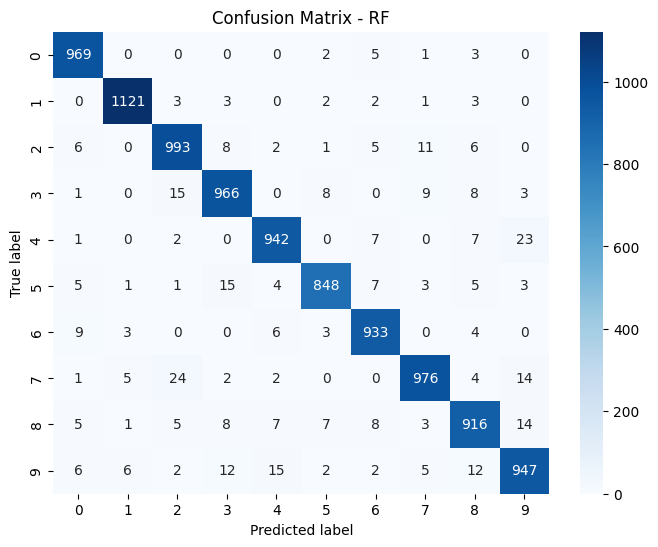

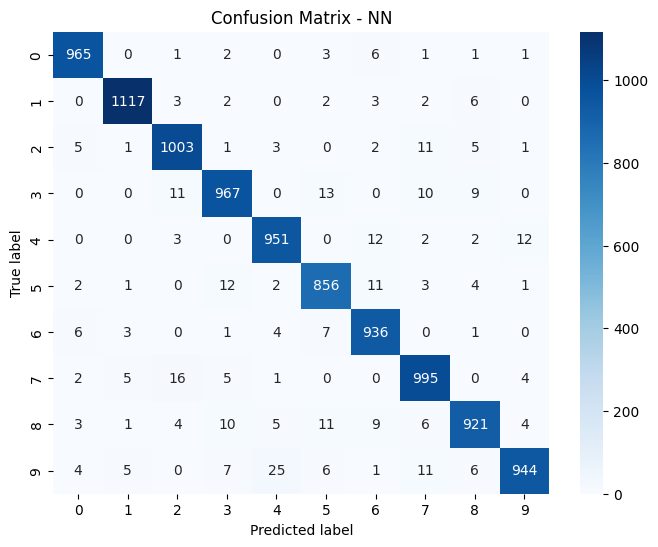

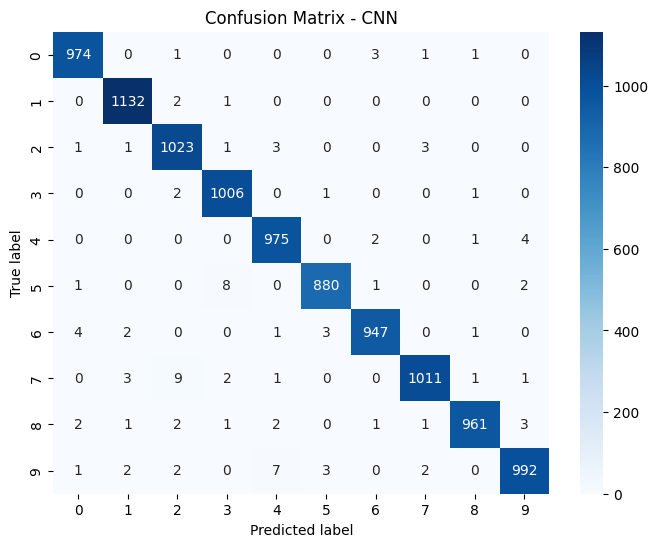

In [15]:
for alg in algorithms:

    cm = results[alg]["confusion_matrix"]

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {alg.upper()}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    plt.show()

Confusion matrices clearly show the differences between the models. 

For Random Forest, the diagonal is dense, but there are noticeable errors:  
it confuses 4 and 9, 5 and 3, 7 and 2 - typical MNIST cases where the pixels just look similar. 

The neural network (NN) performs better, there are fewer errors, but the same problematic pairs remain. 

Meanwhile, the CNN is almost perfect: nearly all digits are on the diagonal, there are very few mistakes.   
It's especially clear how easily it distinguishes similar digits like 4/9 or 5/3, precisely because it captures the shape and structure, not just a set of points.  
Overall, the CNN’s matrix is the cleanest, which again confirms why convolutional networks are best suited for images.

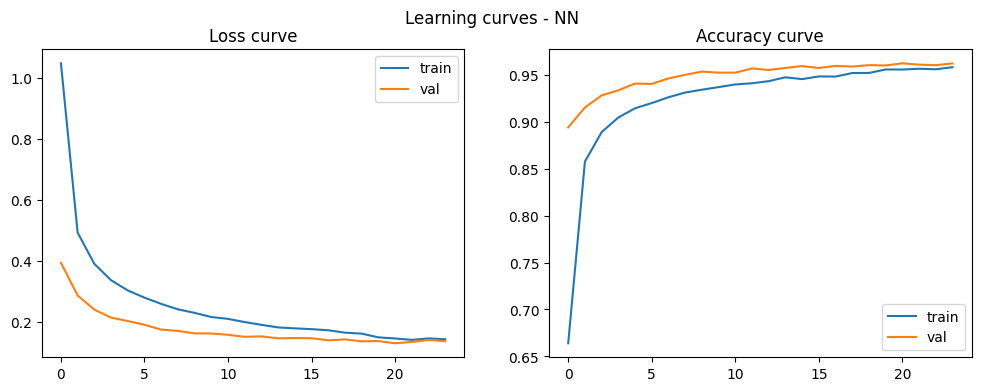

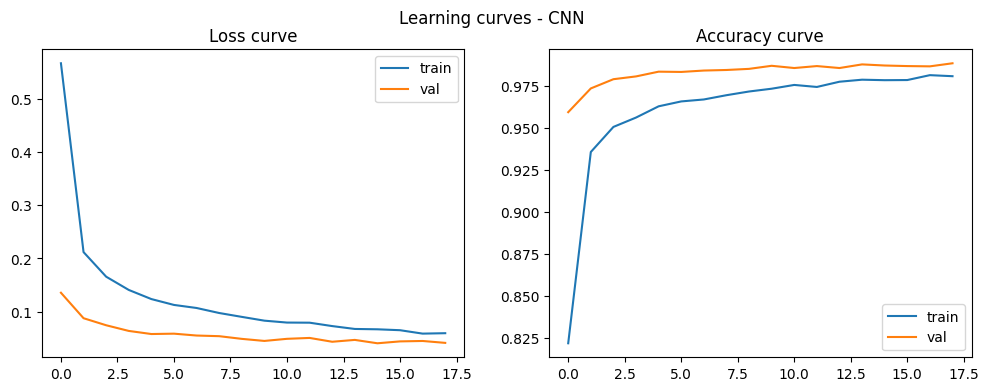

In [16]:
for alg in ["nn","cnn"]:

    clf = trained_models[alg]

    history = clf.get_metrics()

    fig, axes = plt.subplots(1,2, figsize=(12,4))

    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title("Loss curve")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title("Accuracy curve")
    axes[1].legend()

    fig.suptitle(f"Learning curves - {alg.upper()}")

    plt.show()

The learning curves for the NN and CNN show that both models train smoothly.    
Loss steadily goes down while accuracy rises fast at the beginning and then levels off. 

For the NN the training and validation lines stay close, so overfitting is minimal.

The CNN looks even better: both train and validation loss drop quickly and smoothly right from the start,   
staying close together without any big gaps, which means the model is learning efficiently without overfitting.     
Accuracy climbs fast in the first few epochs and then stabilizes nicely around 97-98%.

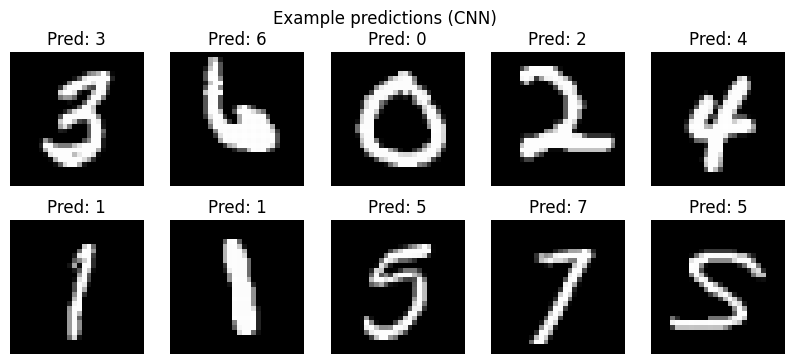

In [ ]:
model = trained_models["cnn"]

indices = np.random.choice(len(X_test), 10)

fig, axes = plt.subplots(2,5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    img = X_test[idx]
    pred = model.predict(img.reshape(1,28,28))[0]

    ax.imshow(img, cmap="gray")
    ax.set_title(f"Pred: {pred}")
    ax.axis("off")

plt.suptitle("Example predictions (CNN)")

plt.show()

## Performance Comparison

Table with test accuracies

In [18]:
df = pd.DataFrame(results).T
df = df[["test_accuracy"]]
df

,test_accuracy
rf,0.9611
nn,0.9655
cnn,0.9901


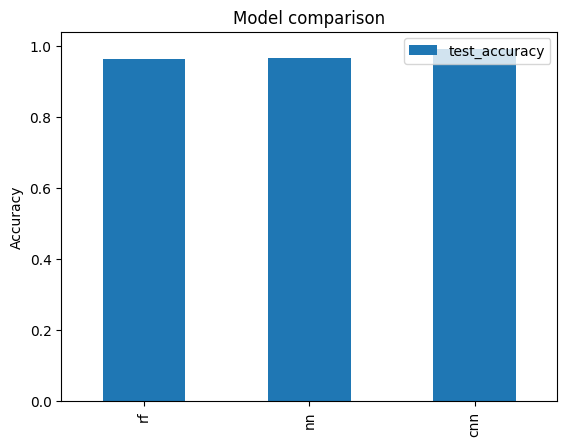

In [19]:
df.plot.bar()

plt.title("Model comparison")
plt.ylabel("Accuracy")
plt.show()

## Edge Cases

To demonstrate robustness, we test edge cases.


### Edge case 1: Small training set

We train the models on a very small subset of the data (100 samples).  
This simulates a scenario with extremely limited labeled data.

Expected behavior:
- Models should train successfully
- Accuracy should be low due to underfitting

In [20]:
from sklearn.metrics import accuracy_score

small_X = X_train[:100]
small_y = y_train[:100]

print("Training with only 100 samples")

small_models = {}

for alg in ["rf", "nn", "cnn"]:
    model = MnistClassifier(algorithm=alg, epochs=5)
    model.train(small_X, small_y)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    small_models[alg] = acc
    
    print(f"{alg.upper()} accuracy with small dataset:", acc)

Training with only 100 samples
RF accuracy with small dataset: 0.6884
NN accuracy with small dataset: 0.2011
No validation set provided; early stopping disabled.
Epoch 1/5 | Train Loss: 2.3191, Acc: 0.1000
Epoch 2/5 | Train Loss: 2.3454, Acc: 0.2000
Epoch 3/5 | Train Loss: 2.2344, Acc: 0.2000
Epoch 4/5 | Train Loss: 1.9630, Acc: 0.2700
Epoch 5/5 | Train Loss: 1.7384, Acc: 0.3900
CNN accuracy with small dataset: 0.3735


### Edge case 2: Noisy inputs

We add Gaussian noise to the test images to simulate corrupted input data.

Expected behavior:
- Accuracy should decrease
- CNN may handle noise better due to spatial filters

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score

noise = np.random.normal(0, 50, X_test.shape)

X_test_noisy = np.clip(X_test + noise, 0, 255)

print("Evaluating on noisy images")

for name, model in trained_models.items():
    preds = model.predict(X_test_noisy)
    acc = accuracy_score(y_test, preds)
    
    print(f"{name.upper()} accuracy on noisy images:", acc)

Evaluating on noisy images
RF accuracy on noisy images: 0.6447
NN accuracy on noisy images: 0.8289
CNN accuracy on noisy images: 0.9746


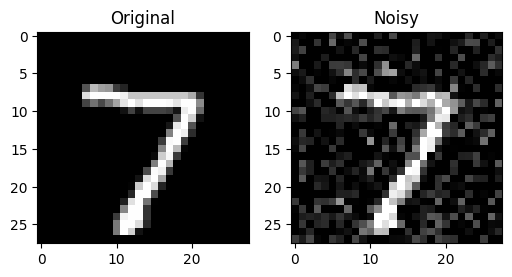

In [22]:
import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(X_test[idx], cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(X_test_noisy[idx], cmap="gray")
plt.title("Noisy")

plt.show()

### Edge case 3: Invalid input shapes

We pass inputs with incorrect dimensions (30x30 instead of 28x28).

Expected behavior:
- The model should raise an error
- This confirms that input validation works correctly

In [23]:
invalid_input = np.random.rand(5, 30, 30)

try:
    preds = trained_models["cnn"].predict(invalid_input)
    print("Prediction succeeded unexpectedly:", preds)

except Exception as e:
    print("Error correctly raised:")
    print(type(e).__name__, "-", e)

Error correctly raised:
ValueError - Expected images (N, 28, 28), got shape (5, 30, 30)


### Edge case 4: Empty input

We test prediction on an empty batch.

Expected behavior:
- The model should return an empty array
- No crash should occur

In [24]:
empty_input = np.empty((0, 28, 28))

preds = trained_models["cnn"].predict(empty_input)

print("Prediction shape:", preds.shape)
print("Predictions:", preds)

Prediction shape: (0,)
Predictions: []


### Edge case 5: Non-Image data

We pass completely random data that does not resemble MNIST digits.

Expected behavior:
- The model should still return predictions
- Accuracy should be very low

In [25]:
random_data = np.random.randint(0, 255, (100, 28, 28))
random_labels = np.random.randint(0, 10, 100)

preds = trained_models["cnn"].predict(random_data)

acc = accuracy_score(random_labels, preds)

print("Accuracy on random data:", acc)

Accuracy on random data: 0.13


## Training on the full dataset (optional experiment)

In [26]:
print("Training CNN on full dataset")

cnn_full = MnistClassifier("cnn", epochs=40, batch_size=128, patience=3)
cnn_full.train(X_train_full, y_train_full)

preds = cnn_full.predict(X_test)
full_acc = accuracy_score(y_test, preds)

print("Test accuracy (full dataset):", full_acc)

Training CNN on full dataset
No validation set provided; early stopping disabled.
Epoch 1/40 | Train Loss: 0.3452, Acc: 0.8933
Epoch 2/40 | Train Loss: 0.1440, Acc: 0.9574
Epoch 3/40 | Train Loss: 0.1206, Acc: 0.9640
Epoch 4/40 | Train Loss: 0.1024, Acc: 0.9691
Epoch 5/40 | Train Loss: 0.0922, Acc: 0.9719
Epoch 6/40 | Train Loss: 0.0874, Acc: 0.9735
Epoch 7/40 | Train Loss: 0.0788, Acc: 0.9753
Epoch 8/40 | Train Loss: 0.0751, Acc: 0.9776
Epoch 9/40 | Train Loss: 0.0725, Acc: 0.9784
Epoch 10/40 | Train Loss: 0.0677, Acc: 0.9790
Epoch 11/40 | Train Loss: 0.0633, Acc: 0.9806
Epoch 12/40 | Train Loss: 0.0604, Acc: 0.9815
Epoch 13/40 | Train Loss: 0.0590, Acc: 0.9823
Epoch 14/40 | Train Loss: 0.0527, Acc: 0.9833
Epoch 15/40 | Train Loss: 0.0529, Acc: 0.9838
Epoch 16/40 | Train Loss: 0.0531, Acc: 0.9836
Epoch 17/40 | Train Loss: 0.0506, Acc: 0.9838
Epoch 18/40 | Train Loss: 0.0469, Acc: 0.9853
Epoch 19/40 | Train Loss: 0.0435, Acc: 0.9862
Epoch 20/40 | Train Loss: 0.0453, Acc: 0.9857
Epoch 2

## Final Conclusions

The results turned out strong. On a 30000-sample subset, Random Forest reached 96.11%, the simple neural network got 96.55%,    
and the CNN clearly won with 99.01%.  

When we trained the CNN on the full 60000 images, it hit 99.42%.   

Overfitting stayed under control across all models. Random Forest memorized the training set perfectly (100%)   
but still generalized well to 96.11% on test - expected gap for tree-based models. 

The neural networks were even better: NN had about a 2.1% difference and CNN only ~0.7%. 

The learning curves looked healthy and smooth. For CNN, loss dropped quickly and steadily, with train and validation staying very close the whole time.     
NN followed a similar pattern but converged a bit slower with a slightly larger gap toward the end.

Edge cases worked as expected: on tiny 100-sample sets accuracy dropped sharply (underfitting),     
noisy images hurt all models but CNN held up best (97.5% vs 64.5% for RF),  
empty inputs returned empty arrays without crashing, random garbage gave 13% accuracy, and invalid shapes correctly raise an error.